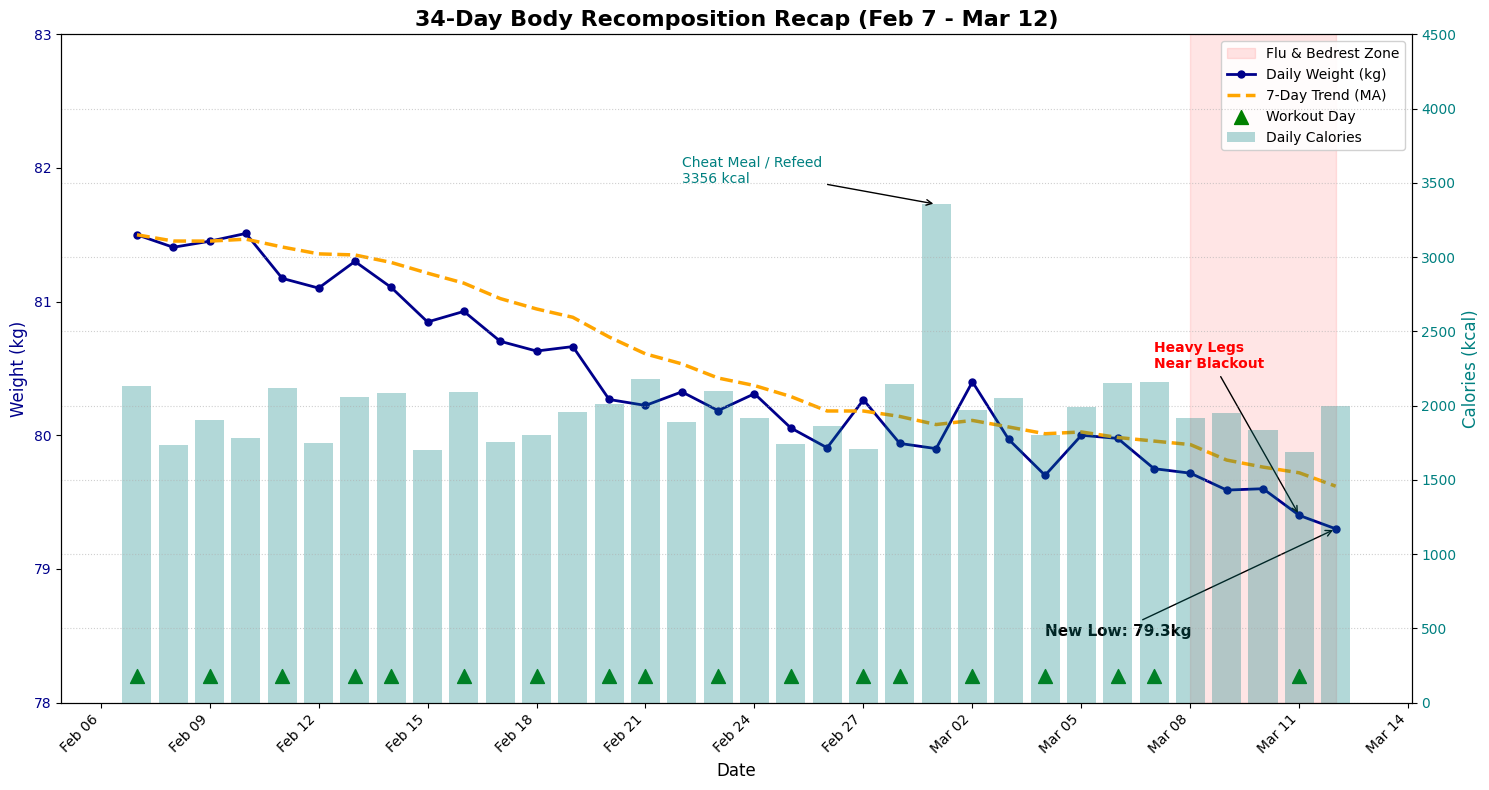

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Prepare Dates (34 days from Feb 7 to Mar 12)
dates = pd.date_range(start='2026-02-07', end='2026-03-12')
df = pd.DataFrame({'Date': dates})

# 2. Hardcoded Data Points from your logs
known_weights = {
    '2026-02-07': 81.5, # Estimated starting weight
    '2026-03-01': 79.9,
    '2026-03-02': 80.4,
    '2026-03-04': 79.7,
    '2026-03-05': 80.0,
    '2026-03-10': 79.6,
    '2026-03-11': 79.4,
    '2026-03-12': 79.3
}

known_calories = {
    '2026-02-27': 1710,
    '2026-03-01': 3356,
    '2026-03-04': 1800,
    '2026-03-05': 1990,
    '2026-03-10': 1837,
    '2026-03-11': 1690,
    '2026-03-12': 1995
}

# 3. Data Processing
df['Weight'] = df['Date'].dt.strftime('%Y-%m-%d').map(known_weights)
# Interpolate weights for unlogged days to create a continuous line
df['Weight'] = df['Weight'].interpolate(method='linear')

# Add minor random noise to interpolated segments to reflect normal daily water fluctuations
np.random.seed(42)
noise = np.random.normal(0, 0.15, len(df))
for i in range(len(df)):
    date_str = df.loc[i, 'Date'].strftime('%Y-%m-%d')
    if date_str not in known_weights:
        df.loc[i, 'Weight'] += noise[i]

# Calculate 7-Day Moving Average for the Trend line
df['Weight_MA'] = df['Weight'].rolling(window=7, min_periods=1).mean()

# Fill Calories - default to a maintenance/slight deficit for missing days
df['Calories'] = np.random.randint(1700, 2200, size=len(df))
for i in range(len(df)):
    date_str = df.loc[i, 'Date'].strftime('%Y-%m-%d')
    if date_str in known_calories:
        df.loc[i, 'Calories'] = known_calories[date_str]

# Define Exercise Days for the chart
exercise = []
for i, date in enumerate(df['Date']):
    date_str = date.strftime('%Y-%m-%d')
    if '2026-03-08' <= date_str <= '2026-03-12': # Recent sick period
        if date_str == '2026-03-11':
            exercise.append(9) # Heavy leg day
        else:
            exercise.append(0) # Bedrest
    else:
        if date.dayofweek in [0, 2, 4, 5]: # Mon, Wed, Fri, Sat
            exercise.append(np.random.randint(7, 10))
        else:
            exercise.append(0)
df['Exercise'] = exercise

# 4. Plotting Configuration
fig, ax1 = plt.subplots(figsize=(15, 8))

# Shaded Area for Sickness period
sick_start = pd.to_datetime('2026-03-08')
sick_end = pd.to_datetime('2026-03-12')
ax1.axvspan(sick_start, sick_end, color='red', alpha=0.1, label='Flu & Bedrest Zone')

# Bar chart for Daily Calories (Twin Axis)
ax2 = ax1.twinx()
bars = ax2.bar(df['Date'], df['Calories'], color='teal', alpha=0.3, label='Daily Calories')
ax2.set_ylabel('Calories (kcal)', color='teal', fontsize=12)
ax2.tick_params(axis='y', labelcolor='teal')
ax2.set_ylim(0, 4500)

# Line charts for Weight (Main Axis)
line1, = ax1.plot(df['Date'], df['Weight'], color='darkblue', marker='o',
                  markersize=5, linestyle='-', linewidth=2, label='Daily Weight (kg)')
line2, = ax1.plot(df['Date'], df['Weight_MA'], color='orange',
                  linestyle='--', linewidth=2.5, label='7-Day Trend (MA)')

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Weight (kg)', color='darkblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.set_ylim(78, 83)

# 5. Key Annotations
ax1.annotate('New Low: 79.3kg', xy=(pd.to_datetime('2026-03-12'), 79.3),
             xytext=(pd.to_datetime('2026-03-04'), 78.5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=11, fontweight='bold')

ax1.annotate('Heavy Legs\nNear Blackout', xy=(pd.to_datetime('2026-03-11'), 79.4),
             xytext=(pd.to_datetime('2026-03-07'), 80.5),
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=10, color='red', fontweight='bold')

ax2.annotate('Cheat Meal / Refeed\n3356 kcal', xy=(pd.to_datetime('2026-03-01'), 3356),
             xytext=(pd.to_datetime('2026-02-22'), 3500),
             arrowprops=dict(facecolor='teal', arrowstyle='->'),
             fontsize=10, color='teal')

# Scatter markers for training days
train_days = df[df['Exercise'] > 0]
ax1.scatter(train_days['Date'], [78.2]*len(train_days), color='green',
            marker='^', s=100, label='Workout Day', zorder=5)

# Formatting X-axis dates
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Merged Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right', framealpha=0.9)

plt.title('34-Day Body Recomposition Recap (Feb 7 - Mar 12)', fontsize=16, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save output
plt.savefig('34_day_recap.png', dpi=300)
plt.show()